In [2]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")

import numpy as np
import copy
from PIL import Image
import cv2
import open3d as o3d
import importlib
import imutils
import matplotlib.pyplot as plt
from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object, label_wrist_image_rotation_axes
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
from magpie_control import poses
import spatialmath as sm
reload_modules(pcd, utils, real, ur5, gripper)

# with help from: https://github.com/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb
import os
from google import genai
import openai
from dotenv import load_dotenv
import instructor
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
reload_modules(sf_force_thinker, sf_grasp_selection, conversation, sf_force_reflection)

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENAI_API_KEY = os.getenv('CORRELL_API_KEY')
GEMINI_MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}
# OPENAI_MODEL_ID = "gpt-4o-mini"
OPENAI_MODEL_ID = "gpt-4o"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
force_thinker = sf_force_thinker.PromptForceThinker()

In [3]:
from magpie_perception.label import Label
from magpie_perception.label_owlvit import LabelOWLViT
from magpie_perception.label_owlv2  import LabelOWLv2
from magpie_perception.label_dino   import LabelDINO
from magpie_perception.mask_sam2    import MaskSAM2

label_models = {'owl-vit': LabelOWLViT(),
                'owl-v2':  LabelOWLv2(),
                'dino':    LabelDINO(),}
mask_models = {'mask': MaskSAM2(),
               'box-dbscan': None}
label_model = label_models['owl-vit']
label_model = label_models['owl-v2']
label_model.init()

/home/will/miniconda3/envs/octo/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-04-10 13:24:52.448154: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-10 13:24:52.448208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-10 13:24:52.552337: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-10 13:24:52.752092: I te

In [4]:
devices = real.poll_devices()
print(devices)
wrist = real.RealSense(fps=15, w=640, h=480, device_name="D405")
wrist.initConnection(device_serial=devices['D405'])
wkspc = real.RealSense(zMax=5, fps=6, w=640, h=480, device_name="D435")
wkspc.initConnection(device_serial=devices['D435'])

{'D435': '832412070344', 'D405': '126122270157'}
There are 2 available devices!
There are 2 available devices!


# Grasp Localization and Initial Motion

black top of the chair
[(array([-1.166e-01,  1.173e-01,  5.405e+02,  3.654e+02], dtype=float32), 0), (array([ 95.737,  68.433, 342.078, 185.051], dtype=float32), 0), (array([321.228, 406.219, 421.397, 479.839], dtype=float32), 0), (array([ -1.75 ,   2.374, 527.753, 257.643], dtype=float32), 0), (array([ -1.336,  -0.4  , 110.902, 109.456], dtype=float32), 0), (array([ 84.938,  69.403, 361.863, 361.58 ], dtype=float32), 0), (array([308.98 , 335.366, 641.088, 480.473], dtype=float32), 0), (array([ -1.03 ,  -1.383, 109.499, 228.373], dtype=float32), 0), (array([ -5.235,  70.068, 527.293, 252.467], dtype=float32), 0), (array([  3.465,  -0.754, 380.565, 359.438], dtype=float32), 0), (array([366.345,  75.333, 424.121, 187.271], dtype=float32), 0), (array([384.085,  43.3  , 600.401, 181.585], dtype=float32), 0), (array([ 75.884, 195.116, 366.61 , 363.69 ], dtype=float32), 0), (array([350.417, 129.352, 569.08 , 262.371], dtype=float32), 0), (array([ 15.083, 397.4  , 320.077, 479.337], dtype=flo

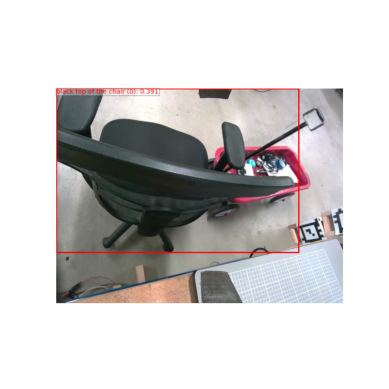

In [8]:
# user_query = "grab the scissors"
# user_query = "grab the screwdriver"
user_query = "grab and turn the chair to the left"
# user_query = "close the blue case"

pcd_wrist, rgbd_wrist = wrist.getPCD()
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()

img_wrist = np.array(rgbd_wrist.color).copy()
img_wkspc = np.array(rgbd_wkspc.color)

grasp_prompt = sf_grasp_selection.grasp_prompt.format(**{"user_query": user_query})
img = Image.fromarray(img_wrist)
image_response = gemini_client.models.generate_content(
    model=GEMINI_MODEL_ID,
    contents=[grasp_prompt, img],
)
# image_response = send_message(gemini_client, model=GEMINI_MODEL_ID, messages=[grasp_prompt, img], model_type="gemini")
grasp_phrase = image_response.text.split("\n")[-1].split(": ")[-1]
print(grasp_phrase)

query = [grasp_phrase]
seg_type = 'box-dbscan'
mask_model = mask_models[seg_type]
pcd_wrist, rgbd_wrist = wrist.getPCD()
pose, pred_image = find_object(rgbd_wrist, query, label_model, mask_model, seg_type, wrist)
np.save("scalingforce/pose.npy", pose)
print(pose)
print(plt.get_backend())
%matplotlib inline
plt.imshow(pred_image)
plt.axis('off')  # Optional: to hide axis values and ticks
plt.show()

In [9]:
ROBOT_IP = "192.168.0.4"
robot = ur5.UR5_Interface(ROBOT_IP, 
                            freq=6, # 6Hz frequency
                            record=False,
                            provide_gripper=True,
                            provide_ft_sensor=True,)
robot.start()
robot.start_ft_sensor()
robot.moveL_translation_tooltip(pose, asynch=False)


Found Dynamixel Port:
/dev/ttyACM0

Succeeded to open the port
Succeeded to change the baudrate
Tooltip: [0.012 0.006 0.211]
Goal Pos: [ 0.217 -0.214  0.416]


# Physical Reasoning for Forceful Motion Plan

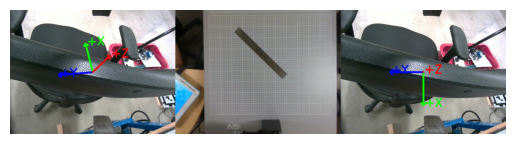

In [10]:
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()
pcd_wrist, rgbd_wrist = wrist.getPCD()
img_wrist = np.array(rgbd_wrist.color)
img_wkspc = np.array(rgbd_wkspc.color)

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
T_wr = np.array(robot.getPose())
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_labeled = label_wrist_image_rotation_axes(img_wrist.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_labeled_base = label_wrist_image_rotation_axes(img_wrist.copy(), R_cr, intrinsics, axis_length=0.03)
final_img = np.hstack((img_wrist_labeled_base, img_wkspc, img_wrist_labeled))
# final_img = np.hstack((wrist_img_labeled, wrist_img2_labeled, ))

# save img
fn = f"scalingforce/axes_{user_query}.png"
cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(final_img)

In [11]:
model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    client_structured = instructor.from_openai(client=client)
    model = OPENAI_MODEL_ID
elif model_type == "gemini":
    client = gemini_client
    client_structured = instructor.from_genai(client=client)
    model = GEMINI_MODEL_ID
img = Image.open('scalingforce/axes7_double_wrist.png').convert("RGB")

# obj = "small servo motor"
prompt_config = {
"obj": grasp_phrase,
"task": user_query
}
# obj = "small servo motor"
# prompt_config = {
# "obj": "small servo motor",
# "task": f"slide the {obj} rapidly up the table for 10 cm"
# }

messages = []
prompt = sf_force_thinker.prompt_motion_thinker.format(**prompt_config)
messages = build_messages(prompt, img, messages=messages, model_type=model_type)
response = send_message(client, model, messages, model_type=model_type)
motion_plan = force_thinker.process_thinker_response(response)
np.save(f"scalingforce/{user_query}_response.npy", response, allow_pickle=True)
np.save(f"scalingforce/{user_query}_motion_plan.npy", motion_plan, allow_pickle=True)
print(response)
messages.append(response)
motion_plan

[start of motion plan]
The task is to grab and turn the chair to the left while grasping the black top of the chair.

Aligning Images With Wrist Motion:
The provided images in the three-part image confirm the presence of a blue toolbox with a black interior and a gray chair. The goal is to grab the black top of the chair and turn it to the left.
The green axis representing the positive X-axis along the wrist corresponds to the world-frame axis that results in motion towards the robot base when the robot arm moves in the green direction, which is turning the chair to the left.
The blue axis representing negative Y-axis along the wrist corresponds to the world-frame axis that results in downward force when the robot moves in the blue direction, which is for maintaining grasp and for vertical alignment to not collide with table during turning.
The red dot representing the positive Z-axis (into the page) along the wrist corresponds to the world-frame axis that provides grasp force to hold 

{'position_direction': [0, 1, 0],
 'position_goal': [0.0, 0.1, 0.0],
 'force': [0.0, 12.0, 0.0, 0.0, 0.0, 0.75],
 'grasp_force': 7.5,
 'duration': 3.0}

# Robot Motion Execution

In [12]:
importlib.reload(ur5)
importlib.reload(gripper)
# ROBOT_IP = "192.168.0.4"
# robot = ur5.UR5_Interface(ROBOT_IP, 
#                             freq=6, # 6Hz frequency
#                             record=False,
#                             provide_gripper=True,
#                             provide_ft_sensor=True,)
# robot.start()
# robot.start_ft_sensor(poll_rate=100)
G = robot.gripper
G.reset_parameters()
np.save("scalingforce/home.npy", robot.home)
pose = np.load("scalingforce/pose.npy")

In [35]:
import numpy as np
motion_plan = np.load("scalingforce/motion_plan.npy", allow_pickle=True).item()
G.reset_and_close_gripper(force_limit=10)
motion_plan

{'position_direction': [0, 1, 0],
 'position_goal': [0.0, 0.1, 0.0],
 'force': [0.0, 12.0, 0.0, 0.0, 0.0, 0.75],
 'grasp_force': 7.5,
 'duration': 3.0}

In [33]:
speed = np.array([0, 0, 0.02, 0, 0, 0.00])
robot.speedL_TCP(speed, tooltip=True)

In [34]:
speed = np.array([0, 0, 0, 0, 0, 0.0])
robot.speedL_TCP(speed, tooltip=True)

In [30]:
G.reset_parameters()

In [56]:
camera_dict = {
    wrist: "record/wrist/",
    wkspc: "record/workspace/"
}
goal_delta = np.array(motion_plan['position_goal'])
direction = np.array(motion_plan['position_direction'])
sign = np.where(np.hstack((direction, np.zeros(3))) < 0, -1, 1)
force = np.array(motion_plan['force']) * sign * -1
# force = np.array(motion_plan['force']) * sign 
wrench_goal = force
init_cmd = np.hstack((force[:3] / 300, force[3:] / 15))
# wrench_goal = np.hstack((force, np.zeros(3)))
# init_cmd = np.hstack((force / -300, np.zeros(3)))
# duration = motion_plan['duration']
duration = 8
grasp_force = motion_plan['grasp_force']
P = 0.0003 # stiffness gain, default is 0.0005

# TODO: add a re-zero ft sensor function, but for now just restart it
robot.start_ft_sensor()

init_cmd

array([-0.  , -0.04, -0.  , -0.  , -0.  , -0.05])

In [57]:
motion_log = await robot.concurrent_gripper_camera_robot_control(wrench=wrench_goal, goal_delta=goal_delta, grasp_force=grasp_force, 
                                         camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.01, 
                                         duration=duration, p=P, control_type="bang_bang")
robot.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)


D405 Recording Started
D435 Recording Started
D405 Recording Task Cancelled
D405 Recording Stopped
D435 Recording Task Cancelled
D435 Recording Stopped


True

In [77]:
import time
import os
log_time = time.time()
log_name = f"scalingforce/{user_query}_log_{log_time}"
text_messages = [i for i in messages if type(i) == str]
# create directory if it doesn't exist
if not os.path.exists(log_name):
    os.makedirs(log_name)
np.save(f"{log_name}/query_image.npy", final_img, allow_pickle=True)
np.save(f"{log_name}/messages.npy", text_messages, allow_pickle=True)
np.save(f"{log_name}/gripper_log.npy", motion_log['gripper'],allow_pickle=True)
np.save(f"{log_name}/robot_log.npy", motion_log['robot'],allow_pickle=True)
np.save(f"{log_name}/wrist_log.npy", motion_log['record/wrist/'],allow_pickle=True)
np.save(f"{log_name}/wkspc_log.npy", motion_log['record/workspace/'],allow_pickle=True)

In [66]:
for key in motion_log:
    ts = motion_log[key].keys()
    last_ts = sorted(ts)[-1]
    first_ts = sorted(ts)[0]
    print(f"sensor {key} first timestamp: {first_ts}")
    print(f"sensor {key} last timestamp: {last_ts}")
    duration = last_ts - first_ts
    length = len(motion_log[key])
    print(f"sensor {key} duration: {duration}, length: {length}, Hz: {length/duration}\n")

sensor gripper first timestamp: 1744315377.9529428
sensor gripper last timestamp: 1744315380.8024538
sensor gripper duration: 2.849510908126831, length: 18, Hz: 6.316873519825397

sensor robot first timestamp: 1744315377.889113
sensor robot last timestamp: 1744315385.8730178
sensor robot duration: 7.983904838562012, length: 391, Hz: 48.97352960815392

sensor record/wrist/ first timestamp: 1744315377.7783196
sensor record/wrist/ last timestamp: 1744315385.8457568
sensor record/wrist/ duration: 8.067437171936035, length: 51, Hz: 6.321710217640399

sensor record/workspace/ first timestamp: 1744315377.529811
sensor record/workspace/ last timestamp: 1744315385.7145092
sensor record/workspace/ duration: 8.184698343276978, length: 50, Hz: 6.108960636413763



# Feedback

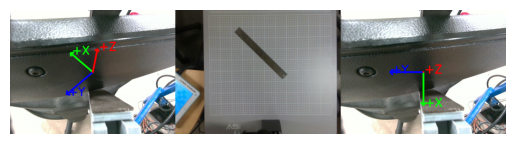

In [85]:
gripper_log = motion_log['gripper']
robot_log   = motion_log['robot']
wrist_log   = motion_log['record/wrist/']
wkspc_log   = motion_log['record/workspace/']
gripper_ts   = sorted(gripper_log.keys())
robot_ts     = sorted(robot_log.keys())
wrist_ts     = sorted(wrist_log.keys())
wkspc_ts     = sorted(wkspc_log.keys())

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
T_wr = np.array(sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[robot_ts[-1]]['actual_TCP_pose']))))
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_final = wrist_log[wrist_ts[-1]]['rgb']
img_wkspc_final = wkspc_log[wkspc_ts[-1]]['rgb']
img_wrist_final_labeled = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_final_labeled_base = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cr, intrinsics, axis_length=0.03)
feedback_img = np.hstack((img_wrist_final_labeled_base, img_wkspc_final, img_wrist_final_labeled))
# final_img = np.hstack((wrist_img_labeled, wrist_img2_labeled, ))

# save img
# fn = f"scalingforce/axes_feedback_{user_query}.png"
# cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(feedback_img)

In [90]:
from spatialmath.base import rodrigues, tr2rpy
import numpy as np

motion_report = ""
motion_report += f"Initial Motion Plan: {motion_plan}\n"
# get first and last TCP pose of robot log
first_pose = np.array(robot_log[robot_ts[0]]['actual_TCP_pose'])
last_pose =  np.array(robot_log[robot_ts[-1]]['actual_TCP_pose'])
dist =  last_pose - first_pose
# get the rotation matrix from the wrist frame to the robot frame
rot = rodrigues(first_pose[3:6])
# transform distance to be relative to the first TCP wrist frame, use inverse of rot
dist_wrist = rot.T @ dist[:3]
motion_report += f"Motion Plan Results: \nDistance traveled relative to original wrist base frame [x, y, z] (m) axes: {dist_wrist.round(3)}\n"
motion_report += f"Distance traveled along base frame [x, y, z] (m) axes: {dist[:3].round(3)}\n"

# Use a simple moving average with a window size of downsample_factor
def moving_average(data, window_size):
    return np.array([np.mean(data[i:i+window_size], axis=0) for i in range(0, len(data), window_size)])

def get_report(desired_freq, timestamps, log, name, description):
    log_dur = timestamps[-1] - timestamps[0]
    log_flat = np.array([log[i][name] for i in timestamps])
    num_downsampled_entries = int(log_dur // (1 / desired_freq))
    downsample_factor = len(timestamps) // num_downsampled_entries
    downsampled_log = moving_average(log_flat, downsample_factor)
    summary = f"\n{description} Log Summary:"
    summary += f"\nMotion Duration: {log_dur}s"
    summary += f"\nAverage {name} Downsampled at {desired_freq}Hz:"
    for i, entry in enumerate(downsampled_log):
        summary += f"\n{i*(1/desired_freq)}s to {(i+1)*(1/desired_freq)}: {entry.round(2)}"
    return summary
desired_freq = 2
wrench_report = get_report(desired_freq, robot_ts, robot_log, "wrench", "6D Wrench [x, y, z, rx, ry, rz] (N and Nm)")
# print(wrench_report)
motion_report += f"{wrench_report}\n"

gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf", "Gripper Contact Force (N)")
# print(gripper_report)
motion_report += f"{gripper_report}\n"

print(motion_report)

Initial Motion Plan: {'position_direction': [0, 1, 0], 'position_goal': [0.0, 0.1, 0.0], 'force': [0.0, 12.0, 0.0, 0.0, 0.0, 0.75], 'grasp_force': 7.5, 'duration': 3.0}
Motion Plan Results: 
Distance traveled relative to original wrist base frame [x, y, z] (m) axes: [-0.055 -0.297 -0.   ]
Distance traveled along base frame [x, y, z] (m) axes: [-0.251 -0.168 -0.002]

6D Wrench [x, y, z, rx, ry, rz] (N and Nm) Log Summary:
Motion Duration: 7.983904838562012s
Average wrench Downsampled at 2Hz:
0.0s to 0.5: [-9.13 -3.78  6.66  0.15 -0.85  0.1 ]
0.5s to 1.0: [-5.82  1.32 -3.43 -0.48 -0.49  0.06]
1.0s to 1.5: [ 0.02  2.16 -7.99 -0.56  0.28  0.06]
1.5s to 2.0: [  3.69   2.12 -11.09  -0.52   0.76   0.07]
2.0s to 2.5: [  5.42   1.65 -12.9   -0.43   1.01   0.09]
2.5s to 3.0: [  5.42   0.73 -11.19  -0.3    0.99   0.09]
3.0s to 3.5: [  3.33  -0.29 -10.59  -0.17   0.69   0.08]
3.5s to 4.0: [  2.34  -0.64 -10.1   -0.12   0.57   0.03]
4.0s to 4.5: [ 0.5  -0.83 -7.33 -0.12  0.37 -0.05]
4.5s to 5.0: [-

In [92]:
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection
from magpie_prompts import conversation
reload_modules(conversation, sf_force_thinker, sf_grasp_selection, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message

feedback_messages = messages.copy()
feedback_messages.append(response)
feedback_prompt_config = prompt_config.copy()
feedback_prompt_config['results'] = motion_report
feedback_prompt = sf_force_reflection.prompt_motion_reflection.format(**feedback_prompt_config)
img_final_PIL = Image.fromarray(final_img).convert("RGB")
feedback_messages = build_messages(feedback_prompt, img_final_PIL, messages=feedback_messages, model_type=model_type)
feedback_response = send_message(client, model, feedback_messages, model_type=model_type)

print(feedback_response)
force_reflector = sf_force_reflection.PromptForceReflection()
motion_feedback_plan = force_reflector.process_thinker_response(feedback_response)
print(motion_feedback_plan)

[beginning of reflection]
Reflection on Task Completion:
- The provided three-part image and change in position confirms the robot was not able to accomplish the task of grab and turn the chair to the left while grasping the black top of the chair.
- This is because, based on the following observations: the change in position relative to the wrist was [-0.055 -0.297 -0.   ] m and base frame was [-0.251 -0.168 -0.002] m, respectively. The large change in negative Y axis position confirms the robot translated *downwards* rather than grasping and rotating. The initial intent was to have very little motion in the X and Z wrist axes, which matched to the base frame. A position update will be required to accomplish the task
- If the task was incomplete, describe the task state: The task is a complete failure, as the robot moved in the incorrect direction. The robot needs to reset and follow an updated plan.
- The estimated task duration was insufficient with the actual task duration.

Reflec